<a href="https://colab.research.google.com/github/pressleydavid/hw4/blob/main/HW4_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summarizing Student Data Graphically

## Bring in HW3 Code


*   Copy code and markdown cells from homework 3 that read in the data and summarized it numerically.




# Summarizing Data Numerically

## Task 1: Read in the data

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [ ]:
import pandas as pd
url = "https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt"
student_data = pd.read_csv(url, delimiter=';')
student_data.head()
# student_data.columns



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Categorical Variables

#### One way contingency table

In [ ]:
# One way contingency table
print("One way table")
# display(student_data.crosstab("sex"))
display(pd.crosstab(index=student_data.sex, columns="count", margins=True))

#check
# student_data.sex.count()



One way table


col_0,count,All
sex,,
F,208,208
M,187,187
All,395,395


Unique categories after renaming: ['Female', 'Male']
Categories (2, object): ['Female', 'Male']
Value counts:
sex
Female    208
Male      187
Name: count, dtype: int64


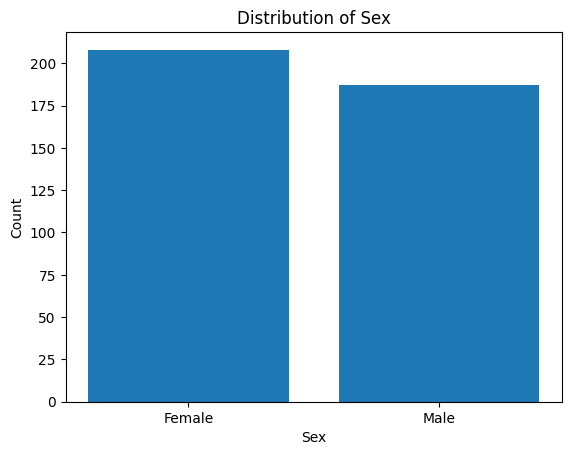

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the student_data DataFrame to ensure it's in the correct state
url = "https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt"
student_data = pd.read_csv(url, delimiter=';')

# Ensure 'sex' column is categorical
student_data["sex"] = student_data["sex"].astype("category")

# Rename categories directly on the column within the DataFrame
student_data["sex"] = student_data["sex"].cat.rename_categories({"F":"Female", "M":"Male"})

print("Unique categories after renaming:", student_data["sex"].unique())

sex_table = student_data.sex.value_counts()
print("Value counts:")
print(sex_table)

# Side-by-side bar graph using sex_table.index for x-axis labels and sex_table.values for heights
plt.bar(sex_table.index, height=sex_table.values)
plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


##### Interpretation: There are 208 Females and 187 Males in the dataset.

#### Two-way contingency table


In [ ]:
# Two way contingency table
print("Two-way table")
display(pd.crosstab(student_data.age, student_data.sex, margins=True, rownames=["Age"], colnames=["Sex"]))

Two-way table


Sex,Female,Male,All
Age,,,
15,38,44,82
16,54,50,104
17,58,40,98
18,43,39,82
19,14,10,24
20,1,2,3
21,0,1,1
22,0,1,1
All,208,187,395


Sex DType Before astype: object
Sex DType after astype: category
School DType Before astype: object
School DType after astype: category
Sex categories before rename: Index(['F', 'M'], dtype='object')
Sex categories after rename: Index(['Female', 'Male'], dtype='object')
School categories before rename: Index(['GP', 'MS'], dtype='object')
School categories after rename: Index(['Gabriel Pereira', 'Mousinho da Silveira'], dtype='object')


Sex,Female,Male
School,,
Gabriel Pereira,183,166
Mousinho da Silveira,25,21


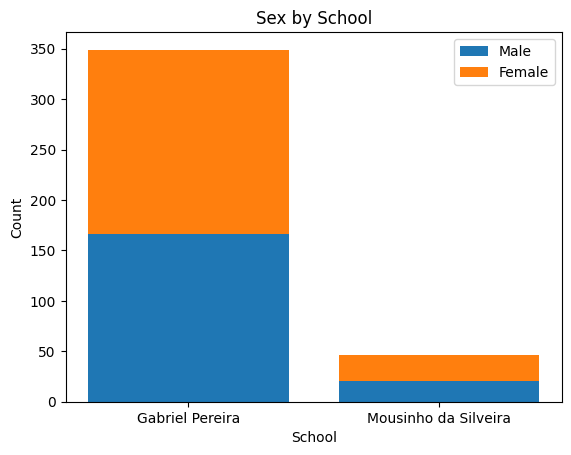

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the student_data DataFrame to ensure it's in the correct state
url = "https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt"
student_data = pd.read_csv(url, delimiter=';')

print(f"Sex DType Before astype: {student_data.sex.dtype}")
student_data["sex"] = student_data["sex"].astype("category")
print(f"Sex DType after astype: {student_data.sex.dtype}")

print(f"School DType Before astype: {student_data.school.dtype}")
student_data["school"] = student_data["school"].astype("category")
print(f"School DType after astype: {student_data.school.dtype}")

print(f"Sex categories before rename: {student_data.sex.cat.categories}")
student_data["sex"] = student_data["sex"].cat.rename_categories({"F":"Female", "M":"Male"})
print(f"Sex categories after rename: {student_data.sex.cat.categories}")

print(f"School categories before rename: {student_data.school.cat.categories}")
student_data["school"] = student_data["school"].cat.rename_categories({"GP":"Gabriel Pereira", "MS":"Mousinho da Silveira"})
print(f"School categories after rename: {student_data.school.cat.categories}")

# Correcting the crosstab creation by removing the 'margin' argument
# Use the student_data DataFrame directly, which now has correctly typed and renamed columns.
stacked_school_table = pd.crosstab(student_data.school, student_data.sex, rownames=["School"], colnames=["Sex"])

display(stacked_school_table)

#get rows for Female
stacked_school_table.loc[:, "Female"]
stacked_school_table.loc[:, "Male"]

#plot stacked bar graph
plt.bar(
    x = student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Male"],
    label = "Male"
)
plt.bar(
    x = student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Female"],
    bottom = stacked_school_table.loc[:,"Male"],
    label = "Female"
)
plt.title("Sex by School")
plt.xlabel("School")
plt.ylabel("Count")
plt.legend(loc = 0)
plt.show()
plt.close()





#### Side-by-Side Bar Chart

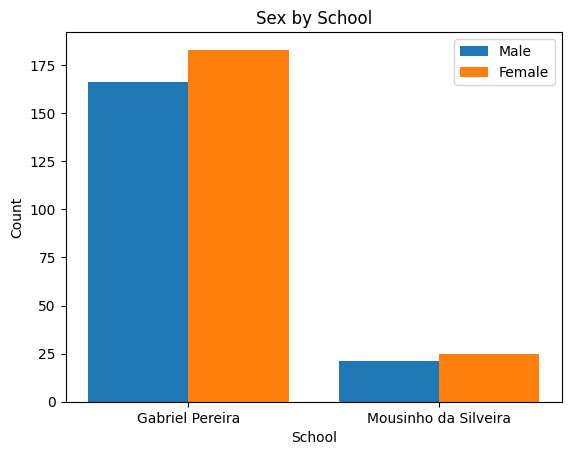

In [ ]:
#plot side-by-side bar graph

plt.bar(
    x = [1, 2],
    # student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Male"],
    width=0.4,
    label = "Male"
)
plt.bar(
    # x = ["Male", "Female"],
    x = [1.4, 2.4],
    # student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Female"],
    width = 0.4,
    label = "Female"
)
index = ["Female","Male"]
stacked_school_table[index]
plt.xticks([1.2, 2.2], student_data.school.cat.categories)
plt.title("Sex by School")
plt.xlabel("School")
plt.ylabel("Count")
plt.legend(loc = 0)
plt.show()
plt.close()

Create visualizations (histogram, kernel density plot, and boxplot) for two numeric variables grouped by a categorical variable to compare distributions.
 Overlay at least one kernel density plot across groups and include appropriate labels and titles for all graphs.



## Numeric Variable Distributions Across Groups

#### Setup data by subsetting `G3`, `studytime`, and `absences`

In [ ]:
from re import sub
import pandas as pd
import matplotlib.pyplot as plt

# Reload the student_data DataFrame to ensure it's in the correct state
url = "https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt"
student_data = pd.read_csv(url, delimiter=';')
# display(student_data.head())

# subset the student_data by selecting the desired columns
# .copy() to create an independent DataFrame instead of a view (prevents SettingWithCopyWarning)
sub_student_data = student_data[["G3", "G1", "famrel", "studytime", "absences", "health"]].copy()
display(sub_student_data.head())
# display(sub_student_data.G3.unique())

# check for continuous
print(f"Unique values before conversion: {sub_student_data.studytime.unique()}")

# discrete. convert to category
sub_student_data["studytime"] = sub_student_data["studytime"].astype("category")

print(f"Dtype after conversion: {sub_student_data['studytime'].dtype}")

# apply labels for studytime
## find category order
print(f"studytime category order before renaming categories: {sub_student_data.studytime.cat.categories}")
sub_student_data.studytime = sub_student_data.studytime.cat.rename_categories(["<2 hours", "2 to 5 hours", "5 to 10 hours", ">10 hours"])
print(f"studytime category order after renaming categories: {sub_student_data.studytime.cat.categories}")



,G3,G1,famrel,studytime,absences,health
0,6,5,4,2,6,3
1,6,5,5,2,4,3
2,10,7,4,2,10,3
3,15,15,3,3,2,5
4,10,6,4,2,4,5


Unique values before conversion: [2 3 1 4]
Dtype after conversion: category
studytime category order before renaming categories: Index([1, 2, 3, 4], dtype='int64')
studytime category order after renaming categories: Index(['<2 hours', '2 to 5 hours', '5 to 10 hours', '>10 hours'], dtype='object')


### Final Grade (G3) by Study Time

##### Histogram: G3 by Study Time

[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]
Statistical Range for <2 hours study time: 19


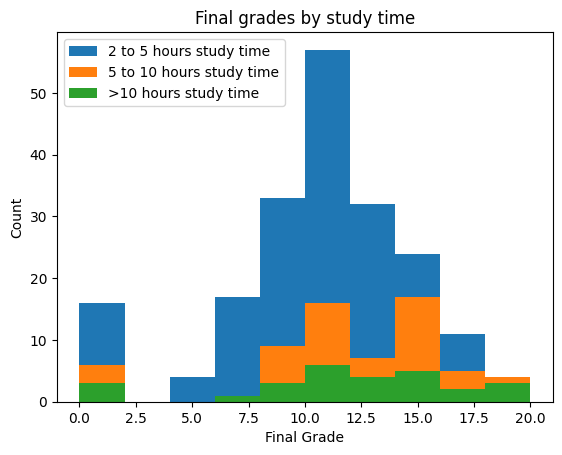

/tmp/ipython-input-1012828257.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_student_data.hist(column = "G3", by = "studytime")


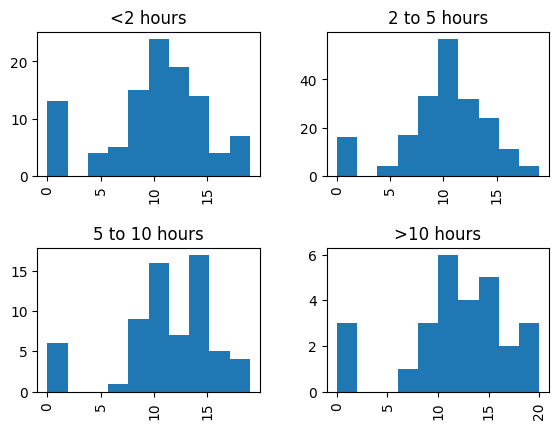

In [ ]:
# Bins
bin_ends = 10
bins = [i*max(sub_student_data.G3)/bin_ends for i in range(0, bin_ends + 1)]
print(bins)

# Subset G3 scores where studytime is "<2 hours" (originally value 1)
g3_studytime1 = sub_student_data.loc[sub_student_data["studytime"] == "<2 hours", "G3"]

# Calculate and print the statistical range
range_1 = g3_studytime1.max() - g3_studytime1.min()
print(f"Statistical Range for <2 hours study time: {range_1}")

# Subset G3 scores where studytime is "2 to 5 hours" (originally value 2)
g3_studytime2 = sub_student_data.loc[sub_student_data["studytime"] == "2 to 5 hours", "G3"]
# g3_studytime2

# Subset G3 scores where studytime is "5 to 10 hours" (originally value 3)
g3_studytime3 = sub_student_data.loc[sub_student_data["studytime"] == "5 to 10 hours", "G3"]
# g3_studytime3

# Subset G3 scores where studytime is ">10 hours" (originally value 4)
g3_studytime4 = sub_student_data.loc[sub_student_data["studytime"] == ">10 hours", "G3"]
# g3_studytime4

# Histogram
g3_studytime2.plot.hist(bins = bins, alpha = 1.0, label="2 to 5 hours study time")
g3_studytime3.plot.hist(bins = bins, alpha = 1.0, label="5 to 10 hours study time",title = "Final grades for students who studied 5 to 10 hours").set(xlabel = "Final Grade")
g3_studytime4.plot.hist(bins = bins, alpha = 1.0, label=">10 hours study time",title = "Final grades for students who studied >10 hours").set(xlabel = "Final Grade")
plt.legend()
plt.title("Final grades by study time")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()


#side-by-side
sub_student_data.hist(column = "G3", by = "studytime")
# plt.title("Final grades by study time")
plt.show()


##### Kernel Density Plot: G3 by Study Time (Overlaid)

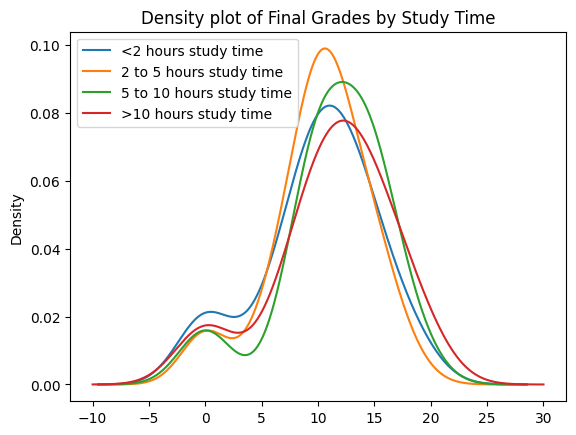

In [ ]:
g3_studytime1.plot.density(bw_method = 0.5, alpha = 1.0, label="<2 hours study time")
g3_studytime2.plot.density(bw_method = 0.5, alpha = 1.0, label="2 to 5 hours study time")
g3_studytime3.plot.density(bw_method = 0.5, alpha = 1.0, label="5 to 10 hours study time")
g3_studytime4.plot.density(bw_method = 0.5, alpha = 1.0, label=">10 hours study time")
plt.legend()
plt.title("Density plot of Final Grades by Study Time")
plt.show()


##### Boxplot: G3 by Study *Time*

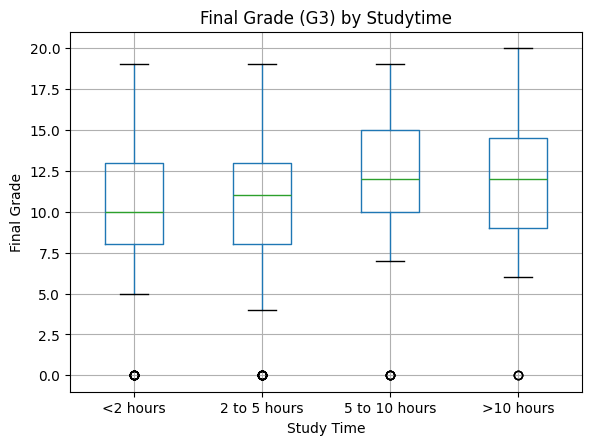

In [ ]:
sub_student_data.boxplot(column = ["G3"], by = "studytime")

# Suppress the automatic title
plt.suptitle("")

# Set the desired chart title
plt.title("Final Grade (G3) by Studytime")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

##### Discussion


### Absences by Study Time

##### Histogram: Absences by Study Time

[0.0, 7.5, 15.0, 22.5, 30.0, 37.5, 45.0, 52.5, 60.0, 67.5, 75.0]


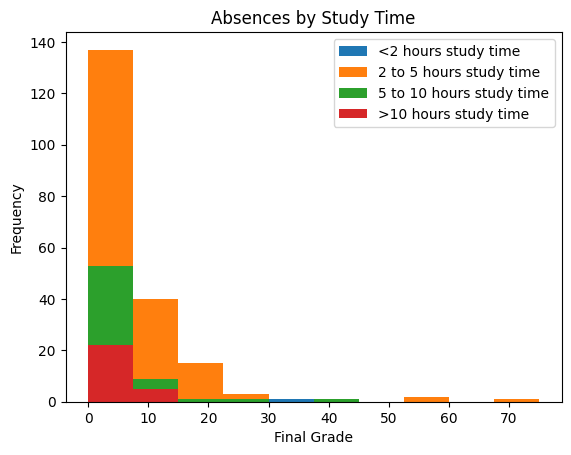

/tmp/ipython-input-3969185405.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_student_data.hist(column = "absences", by = "studytime")


array([[<Axes: title={'center': '<2 hours'}>,
        <Axes: title={'center': '2 to 5 hours'}>],
       [<Axes: title={'center': '5 to 10 hours'}>,
        <Axes: title={'center': '>10 hours'}>]], dtype=object)

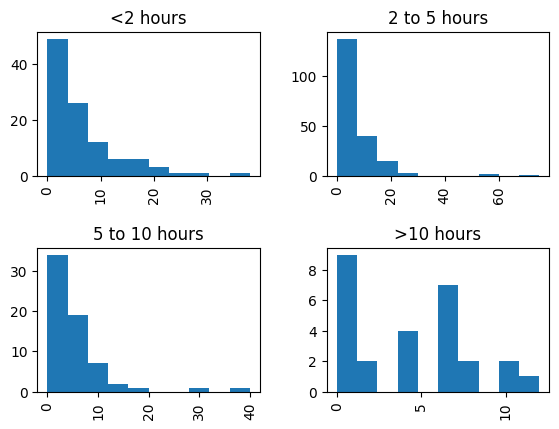

In [ ]:
# Bins
bin_ends = 10
bins = [i*max(sub_student_data.absences)/bin_ends for i in range(0, bin_ends + 1)]
print(bins)

# Subset absences where studytime is "<2 hours" (originally value 1)
ab_studytime1 = sub_student_data.loc[sub_student_data["studytime"] == "<2 hours", "absences"]

# Calculate and print the statistical range
# range_1 = ab_studytime1.max() - ab_studytime1.min()
# print(f"Statistical Range for <2 hours study time: {range_1}")

# Subset absences where studytime is "2 to 5 hours" (originally value 2)
ab_studytime2 = sub_student_data.loc[sub_student_data["studytime"] == "2 to 5 hours", "absences"]
# g3_studytime2

# Subset absences where studytime is "5 to 10 hours" (originally value 3)
ab_studytime3 = sub_student_data.loc[sub_student_data["studytime"] == "5 to 10 hours", "absences"]
# g3_studytime3

# Subset absences where studytime is ">10 hours" (originally value 4)
ab_studytime4 = sub_student_data.loc[sub_student_data["studytime"] == ">10 hours", "absences"]
# g3_studytime4

# Histogram
# sub_student_data.plot.hist(bins = bins, alpha = 1.0, label="Absences", title = "Absences by Study Time")

ab_studytime1.plot.hist(bins = bins, alpha = 1.0, label="<2 hours study time")
ab_studytime2.plot.hist(bins = bins, alpha = 1.0, label="2 to 5 hours study time",title = "Final grades for students who studied 2 to 5 hours")
ab_studytime3.plot.hist(bins = bins, alpha = 1.0, label="5 to 10 hours study time",title = "Final grades for students who studied 5 to 10 hours")
ab_studytime4.plot.hist(bins = bins, alpha = 1.0, label=">10 hours study time")

plt.legend()
plt.xlabel("Final Grade")
plt.title("Absences by Study Time")
plt.show()

#side-by-side
sub_student_data.hist(column = "absences", by = "studytime")

##### Kernel Density Plot: Absences by Study Time

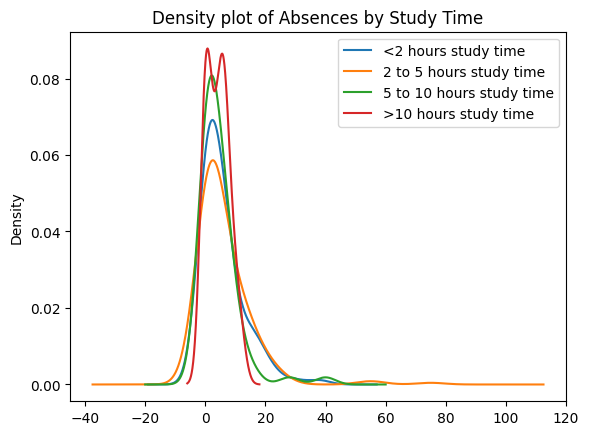

In [ ]:
ab_studytime1.plot.density(bw_method = 0.5, alpha = 1.0, label="<2 hours study time",title = "Absences for students who studied less than 2 hours")
ab_studytime2.plot.density(bw_method = 0.5, alpha = 1.0, label="2 to 5 hours study time",title = "Absences for students who studied 2 to 5 hours")
ab_studytime3.plot.density(bw_method = 0.5, alpha = 1.0, label="5 to 10 hours study time",title = "Absences for students who studied 5 to 10 hours")
ab_studytime4.plot.density(bw_method = 0.5, alpha = 1.0, label=">10 hours study time")
plt.legend()
plt.title("Density plot of Absences by Study Time")
plt.show()

##### Boxplot: Absences by Study Time

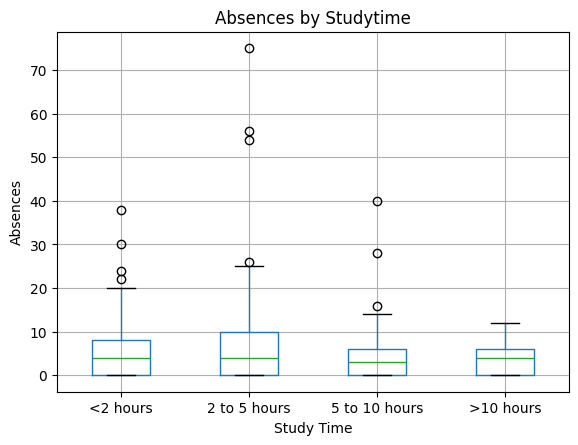

In [ ]:
sub_student_data.boxplot(column = ["absences"], by = "studytime")

# Suppress the automatic title
plt.suptitle("")

# Set the desired chart title
plt.title("Absences by Studytime")
plt.xlabel("Study Time")
plt.ylabel("Absences")
plt.show()

###### Discussion

### Scatterplot of Absences and Final Grade by Health

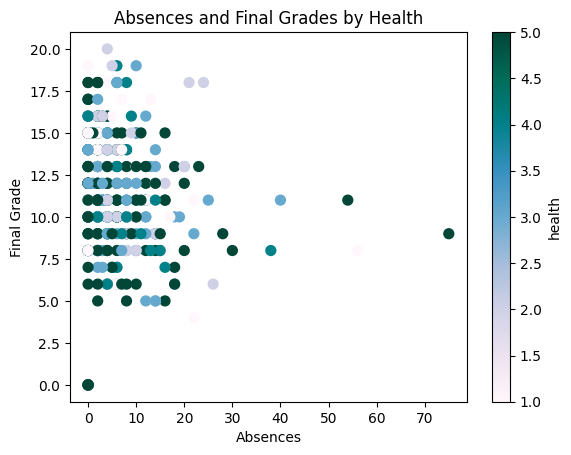

In [ ]:
sub_student_data.plot.scatter(x = "absences", y = "G3", c = "health", cmap = "PuBuGn", s =50)
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences and Final Grades by Health")
plt.show()

### Scatterplot of Initial Grade and Final Grade by Health

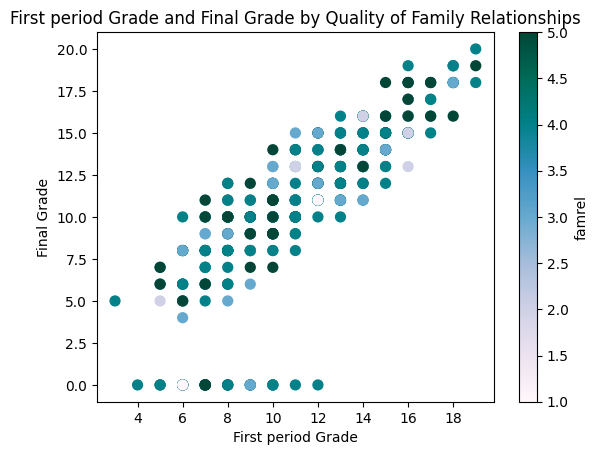

In [ ]:
sub_student_data.plot.scatter(x = "G1", y = "G3", c = "famrel", cmap = "PuBuGn", s = 50)
plt.title("First period Grade and Final Grade by Quality of Family Relationships")
plt.xlabel("First period Grade")
plt.ylabel("Final Grade")
plt.show()



---
---
---



# Plotting the NFL Data

## Strategy

### Read in the Data:

#### Import the dataset from a URL or download it locally.
#### Convert specific columns (homeTeam, awayTeam, day, stadium, startTime, toss, roof, and surface) to categorical variables.
#### Review the first few rows of the dataset.

#### Summarize the Data:
 - Focus on regular season data (weeks 1–17).
 - Summarize variables grouped by:
 - Season and week.
 - Season alone.
 - Week alone.
 - Create numeric summaries and line plots to show trends over time.

#### Write a Function for Plotting:

##### Develop a function to generate plots based on a numeric or categorical variable and a statistic.
##### Include type hints for inputs and use the timeit decorator to measure execution time.
##### Run the function with three different input settings to produce three graphs.

#### Discuss Insights:

#### Provide observations and insights for each graph created.


### Task 1: Read in Data


*   convert vars to category dtypes
*   filter for regular season weeks



In [322]:
import pandas as pd

url = "https://www4.stat.ncsu.edu/~online/datasets/scoresFull.csv"

nfl_src = pd.read_csv("scoresFull.csv")
# nfl_src.head()
# nfl_src.info()
# nfl_src.shape
# nfl_src.columns.tolist()
# nfl_src["week"].unique()

# make a copy for manipulation
nfl_intermed = nfl_src.copy()

# convert vars to category dtype
def convert_to_category(*args):
    for i in convert_list:
        print(f"Before converstion: var: {nfl_src[i].name} dtype: {nfl_src[i].dtype}")
        nfl_intermed[i+"C"] = nfl_src[i].astype("category")
        print(f"After conversion: var: {nfl_intermed[i+"C"].name} dtype: {nfl_intermed[i+"C"].dtype}")
    return None

convert_list = ["homeTeam","awayTeam","day","stadium","startTime","toss", "roof", "surface"]
convert_to_category(convert_list)

(3471, 82)

### Task 2: Summarize the Data

#### Numeric Summaries

In [326]:
# filter for regular season
print(f"Unique week values before filter {nfl_intermed.week.unique()}")

regular_weeks = [str(i) for i in range(1,18)]

nfl_intermed = nfl_intermed.loc[nfl_intermed["week"].isin(regular_weeks), :]
print(f"Unique week values after filter {nfl_intermed.week.unique()}")

nfl_intermed.week.unique()

nfl_intermed["weekN"] = nfl_intermed["week"].astype(int)
nfl_intermed.weekN.unique()

# summarize by season and week
nfl_intermed.info()
reg_season= nfl_intermed.copy()
reg_season = reg_season.loc[:,["season","weekN","AtotalYds","tossC","awayFum","home3rdConv","away3rdConv","awayTimesSacked","homeTimesSacked"]]

# pd.crosstab([reg_season.week], reg_season.tossC)
# group Away total yard statsby season and numerical week (1-17)
reg_season.groupby(["season", "weekN"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2)

# group Away total yard stats by season
reg_season.groupby(["season"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2)

# group Away total yard stats by week (numeric: 1 - 17)
reg_season.groupby(["weekN"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2)


# group Away fumble stats by season and numerical week (1-17)
# use crosstab this time. Then realize creating a list of 3471 elements that only say "stat" doesn't seem like a good use of time and go back to groupby and agg
# pd.crosstab([reg_season.season, reg_season.weekN],
#             columns = ["stat" for _ in range(reg_season.shape[0])],
#             values = reg_season.awayFum,
#             aggfunc = ["mean", "median", "std", "count"]
#             ).round(2)

reg_season.groupby(["season", "weekN"]).agg(
    max_fumA = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2)

# group Away fumble stats by season

reg_season.groupby(["season"]).agg(
    max_fum = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2)

# group Away fumble stats by week (numeric: 1 - 17)
reg_season.groupby(["weekN"]).agg(
    max_fum = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2)


Unique week values before filter ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17']
Unique week values after filter ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17']
<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 0 to 3459
Data columns (total 91 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   week             3328 non-null   object  
 1   date             3328 non-null   object  
 2   day              3328 non-null   object  
 3   season           3328 non-null   int64   
 4   awayTeam         3328 non-null   object  
 5   AQ1              3328 non-null   int64   
 6   AQ2              3328 non-null   int64   
 7   AQ3              3328 non-null   int64   
 8   AQ4              3328 non-null   int64   
 9   AOT              3328 non-null   int64   
 10  AOT2             3328 non-null   int64   
 11  AFinal           3328 non-null   int64   
 12  homeTeam    

,max_fum,min_fum,mean_fum
weekN,,,
1,7,0,1.62
2,6,0,1.51
3,5,0,1.42
4,5,0,1.45
5,4,0,1.37
6,7,0,1.45
7,6,0,1.64
8,6,0,1.39
9,5,0,1.27


#### Time series plots

,weekN,mean_h3rd_conv_by_week,mean_a3rd_conv_by_week
0,1,3.59,3.50
1,2,3.91,3.39
2,3,3.79,3.54
3,4,3.86,3.34
4,5,3.68,3.49
5,6,3.72,3.76
6,7,3.61,3.54
7,8,3.75,3.51
8,9,3.80,3.63
9,10,3.69,3.40


,season,mean_h3rd_conv_by_season,mean_a3rd_conv_by_season
0,2002,3.00,2.80
1,2003,2.67,2.34
2,2004,2.54,2.44
3,2005,2.70,2.44
4,2006,2.69,2.74
5,2007,2.79,2.53
6,2008,2.67,2.65
7,2009,2.86,2.52
8,2010,5.14,5.08
9,2011,5.14,4.93


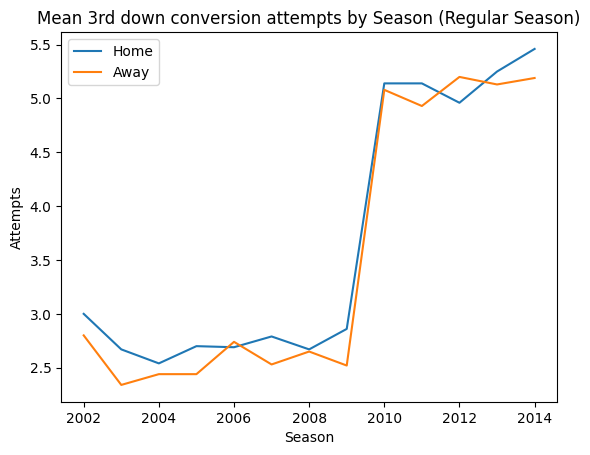

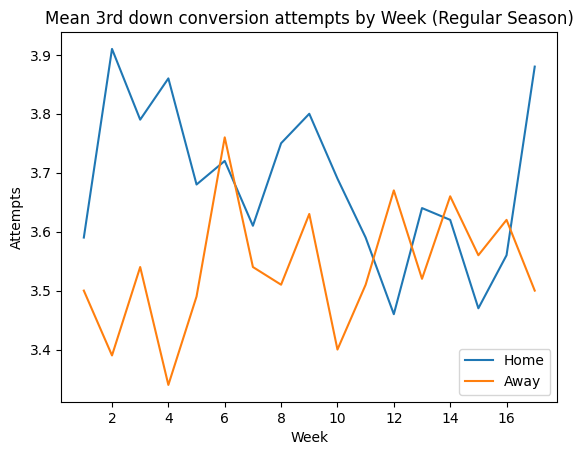

In [385]:

#home3rdConv
#away3rdConv
#awayTimesSacked
#homeTimesSacked

reg_season_plots = reg_season.loc[:,["season","weekN","home3rdConv","away3rdConv","awayTimesSacked","homeTimesSacked"]].copy()

# get the data types of all columns in the DataFrame
reg_season_plots.dtypes

#get info
# reg_season_plots.info()


#plot home and away 3rd down conversion by season and week
#by season
third_down_conv_summ_by_season = reg_season_plots.groupby(["season"]).agg(
    mean_h3rd_conv_by_season = ("home3rdConv", "mean"),
    mean_a3rd_conv_by_season  = ("away3rdConv", "mean")
).round(2).reset_index()

#by week
third_down_conv_summ_by_week = reg_season_plots.groupby(["weekN"]).agg(
    mean_h3rd_conv_by_week = ("home3rdConv", "mean"),
    mean_a3rd_conv_by_week = ("away3rdConv", "mean")
).round(2).reset_index()

display(third_down_conv_summ_by_week)
display(third_down_conv_summ_by_season)

#by season
third_down_conv = third_down_conv_summ_by_season.plot.line(x = "season", y = ["mean_h3rd_conv_by_season","mean_a3rd_conv_by_season"]).legend(["Home","Away"])
plt.title("Mean 3rd down conversion attempts by Season (Regular Season)")
plt.xlabel("Season")
plt.ylabel("Attempts")
plt.show()
plt.close()

#by week
third_down_conv = third_down_conv_summ_by_week.plot.line(x = "weekN", y = ["mean_h3rd_conv_by_week","mean_a3rd_conv_by_week"]).legend(["Home","Away"])
plt.title("Mean 3rd down conversion attempts by Week (Regular Season)")
plt.xlabel("Week")
plt.ylabel("Attempts")
plt.show()
plt.close()



##### Discussion
Mean 3rd down conversions were calculated across regular season weeks and seasons from 2002 to 2014.

For the conversion attempts by season, there was a significant jump in the 2009 season for 3rd down attempts.

For the conversion attempts by week, it seems the homefield advantage comes into play as the home team has significantly more attempts until about week 10, then the away teams close the gap a bit